<!-- criterio de correcao: criar em qualquer celula de resposta uma variavel, funcao, parametro ou chave de dicionario com o nome exato _check -->
# Exercício 7 — Relatório analítico de redes sociais (Projeto 2)

Este exercício é o **Projeto 2**, a entrega final do módulo de redes sociais. Ele não pede coleta nem análise nova: você regenera, com a **sua própria coleta** (a mesma das Aulas 5 e 6, ou uma nova, que seja minimamente variada, com **pelo menos 1000 posts**), a tabela-resumo e os gráficos, e depois preenche o relatório em `RELATORIO-modelo.md`, nesta mesma pasta.

Siga as partes em ordem. Onde houver `# complete aqui`, é o trecho que falta você escrever; o resto já está pronto. O trabalho de escrita de verdade acontece em `RELATORIO-modelo.md`, este notebook só regenera as evidências (tabela e gráficos) que vão dentro dele.

## Preparação do ambiente

Como este notebook mora numa pasta própria (dentro da sua pasta de entregas), crie o ambiente (se ele não existir - cheque a pasta .venv) e instale as dependências (caso aconteça o erro de ModuleNotFound), dentro da pasta raiz:

No Windows (Prompt de Comando/CMD), SE A PASTA .venv não existir:

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

Se o `uv` não funcionar, use `pip install -r requirements.txt` com o ambiente já ativado. No Mac (Terminal), os mesmos comandos funcionam.

## Parte 0 — Dados e pergunta

**Fonte dos dados:** copie a mesma coleta (ou recorte) que você usou nos exercícios das Aulas 5 e 6 para `dados/exportacao.csv` dentro desta pasta.

**Pergunta do relatório:** você já vinha usando uma pergunta analítica desde a Aula 5. Para o relatório final, pode manter a mesma ou ajustá-la, desde que ela seja respondível com a tabela-resumo e os gráficos que você já tem. Anote aqui antes de seguir (você vai copiar isso para `RELATORIO-modelo.md` na Parte 4):

**Pergunta escolhida:**

> Quais as hashtags mais usadas pela clara garcia?

**Por que essa pergunta é a certa para encerrar o Projeto 2:**

> Escolhi essa pergunta porque consigo responder facilmente com os dados coletados. E também é util para saber os assuntos mais falados por ela.

## Parte 1 — Regenerar a tabela-resumo

Mesmo pipeline das Aulas 5, 6 e 7: carregar, remover duplicata, filtrar visualização zero, calcular taxa de engajamento, explodir hashtags e agrupar. Esse trecho já vem pronto; só ajuste os nomes de coluna se a sua plataforma usar nomes diferentes.

In [3]:
import pandas as pd  # pandas para tabela
import matplotlib.pyplot as plt  # matplotlib para gráfico

df = pd.read_csv("dados/exportacao.csv", sep=";")  # lê a sua exportação
df = df.drop_duplicates()  # remove duplicata, se houver

print(f"Linhas depois de remover duplicatas: {len(df)}")

Linhas depois de remover duplicatas: 1030


In [4]:
df_posts = df[df["plays"] > 0].copy()  # só posts com denominador válido (ajuste o nome da coluna se necessário)

df_posts["taxa_engajamento"] = (
    df_posts["likes"] + df_posts["comments"] + df_posts["shares"]
) / df_posts["plays"]  # mesma fórmula das aulas anteriores: interações dividido por visualizações

print(f"Posts com visualização válida: {len(df_posts)}")

Posts com visualização válida: 1030


In [5]:
df_hashtags = df_posts.dropna(subset=["hashtags"]).copy()  # só posts com hashtag preenchida
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.split(",")  # separa a string em lista
df_hashtags = df_hashtags.explode("hashtags")  # uma linha por hashtag
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.strip()  # tira espaço sobrando

resumo_hashtags = df_hashtags.groupby("hashtags").agg(  # agrupa por hashtag
    qtd_posts=("id", "count"),
    curtidas_medias=("likes", "mean"),
    engajamento_medio=("taxa_engajamento", "mean"),
).reset_index().sort_values("engajamento_medio", ascending=False)

resumo_hashtags

,hashtags,qtd_posts,curtidas_medias,engajamento_medio
56,cdb8,1,139500.0,0.293309
121,inscriçãocorridadasblogueiras,1,139500.0,0.293309
139,maychoi,1,139500.0,0.293309
115,hbomaxbr,1,330000.0,0.167703
57,cerejadefases,1,77600.0,0.164188
...,...,...,...,...
230,thetown,1,35100.0,0.007718
119,incrivelnorocinrio,1,20900.0,0.006037
61,claranatim,1,44200.0,0.003594
70,compartilhaumacocacola,1,28400.0,0.003089


In [6]:
resumo_hashtags.to_csv("dados/resumo_hashtags.csv", index=False)  # salva a tabela final, para anexar/citar no relatório
print("Tabela salva em dados/resumo_hashtags.csv")

Tabela salva em dados/resumo_hashtags.csv


## Parte 2 — Regenerar os gráficos

Reaproveite os gráficos que você já fez no exercício da Aula 6 (ou monte de novo aqui). O importante é que a figura seja salva em arquivo com `plt.savefig(...)`, **antes** de `plt.show()`, para poder anexar no relatório.

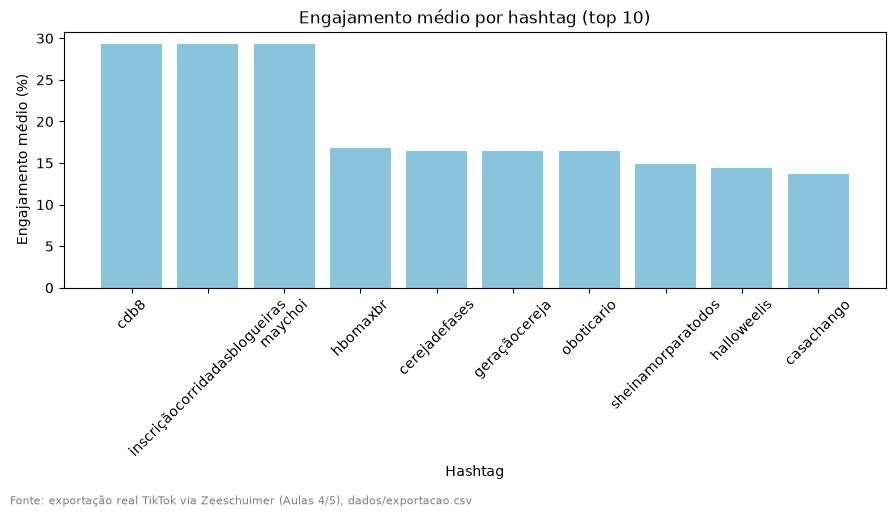

In [16]:
top10 = resumo_hashtags.head(10)  # as 10 hashtags com maior engajamento médio (a tabela já veio ordenada)

fig, ax = plt.subplots(figsize=(9, 5))  # cria a figura e os eixos, com um tamanho legível

ax.bar(top10["hashtags"], top10["engajamento_medio"] * 100, color="#88c4db")  # barra por hashtag; multiplicamos por 100 pra virar porcentagem

ax.set_title("Engajamento médio por hashtag (top 10)")  # título informativo: diz o que o gráfico mostra
ax.set_xlabel("Hashtag")  # rótulo do eixo horizontal
ax.set_ylabel("Engajamento médio (%)")  # rótulo do eixo vertical, com a unidade
ax.tick_params(axis="x", rotation=45)  # gira os nomes das hashtags pra não sobrepor
fig.text(0.01, -0.02, "Fonte: exportação real TikTok via Zeeschuimer (Aulas 4/5), dados/exportacao.csv", fontsize=8, color="gray")  # fonte dos dados, sempre

fig.tight_layout()  # ajusta os espaçamentos pra nada cortar
plt.show()

## Parte 3 — Conferir contra a pergunta da Parte 0

Releia a pergunta que você escreveu na Parte 0. A tabela-resumo e o gráfico que você regenerou respondem essa pergunta? Se a resposta for "só em parte" ou "não", ajuste a pergunta antes de escrever o relatório, não force uma conclusão que os dados não sustentam.

Sim, o gráfico e a tabela respondem a minha pergunta.

## Parte 4 — Escrever o relatório

Agora abra `RELATORIO-modelo.md`, nesta mesma pasta, e preencha as seis seções (pergunta, dados, método, achados, limitações, recomendações), usando a tabela `dados/resumo_hashtags.csv` e o gráfico `dados/grafico_relatorio.png` que você acabou de gerar como evidência.

Lembre da seção 4 da aula: achado é "o que o dado mostra", recomendação é "o que eu sugiro fazer por causa disso". Mantenha essas duas seções separadas, e para cada recomendação, deixe claro de qual achado específico ela depende.

## Parte 5 — Revisão por pares

Troque `RELATORIO-modelo.md` com um colega (ou peça para alguém da turma revisar). Usando os critérios da seção 7 da aula, cada um responde por escrito, no final do relatório do outro:

- A pergunta está clara?
- Os dados batem com o que é dito?
- O método está reproduzível?
- Cada achado tem evidência?
- As conclusões extrapolam a evidência?
- Achado e recomendação estão separados?

Registre os comentários recebidos (e o que você mudou por causa deles, se mudou algo) na seção final de `RELATORIO-modelo.md`.

## Parte 6 — Conferência final

Antes de considerar a entrega concluída, confira:

- [ ] `dados/exportacao.csv` é a mesma coleta (ou recorte) usada nos exercícios das Aulas 5 e 6, e a pasta `dados/` está no `.gitignore`.
- [ ] A tabela-resumo foi regenerada sem erro e salva em `dados/resumo_hashtags.csv`.
- [ ] Pelo menos um gráfico foi regenerado, salvo em arquivo (`plt.savefig(...)` antes de `plt.show()`) e tem título, rótulos e fonte dos dados.
- [ ] `RELATORIO-modelo.md` tem as seis seções preenchidas: pergunta, dados, método, achados, limitações e recomendações.
- [ ] Cada achado no relatório aponta para um número ou gráfico específico, não uma impressão geral.
- [ ] As recomendações estão separadas dos achados, e cada uma indica de qual achado ela depende.
- [ ] A seção de limitações é específica desta coleta, não um parágrafo genérico.
- [ ] O relatório passou por revisão de um colega, e os comentários (e o que mudou por causa deles) estão registrados.
- [ ] Este notebook roda do início ao fim sem erro usando Kernel → Restart e Run All (ou o equivalente no VS Code), não só célula por célula fora de ordem.
- [ ] `RELATORIO-modelo.md` (renomeado se quiser, ex.: `relatorio-final.md`) e este notebook estão copiados dentro de `projetos/07-relatorio-analitico/` na sua pasta de entregas.
- [ ] **Declaração de uso de IA:** ferramenta usada, em que trecho ou decisão desta entrega, e o que você conferiu ou alterou depois do resultado gerado (mesmo que a resposta seja "não usei IA nesta entrega", registre isso em `RELATORIO-modelo.md`).
- [ ] Você já fez `git add`, `git commit` e `git push` dessa entrega.